<a href="https://colab.research.google.com/github/idhayaig-cmd/Taxi-Data-Analysis-and-Visualization/blob/main/Python_DA_Assignment_2_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **2. Load Dataset**

In [ ]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
df.duplicated().sum()

np.int64(0)

# **3) Handling Missing Values**

In [ ]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


**Note**: Based on my observation, the dataset contains missing values in numerical and categorical columns. For numerical columns, I will replace the missing values using the median. For categorical columns, I will replace the missing values using the mode, as it represents the most frequently occurring value.

In [ ]:
df['payment'].mode()

,payment
0,credit card


In [ ]:
df['pickup_zone'].mode()

,pickup_zone
0,Midtown Center


In [ ]:
df['dropoff_zone'].mode()

,dropoff_zone
0,Upper East Side North


In [ ]:
df['pickup_borough'].mode()

,pickup_borough
0,Manhattan


In [ ]:
df['dropoff_borough'].mode()

,dropoff_borough
0,Manhattan


In [ ]:
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])

df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])

df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])

df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])

df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])

In [ ]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


# **4) Visualizations using Matplotlib/Pandas Plot:**

**★ Line Chart**
Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and
fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.

In [ ]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6203,2019-02-28 23:29:03,2019-02-28 23:32:35,1,0.90,5.0,0.0,0.0,6.3,green,cash,Old Astoria,Long Island City/Queens Plaza,Queens,Queens
884,2019-03-01 00:03:29,2019-03-01 00:13:32,3,2.16,10.0,2.0,0.0,15.8,yellow,credit card,Lincoln Square East,Upper East Side North,Manhattan,Manhattan
2882,2019-03-01 00:08:32,2019-03-01 00:29:47,3,7.35,22.5,1.0,0.0,27.3,yellow,credit card,East Chelsea,Mott Haven/Port Morris,Manhattan,Bronx
4212,2019-03-01 00:15:53,2019-03-01 00:47:58,1,7.00,25.5,7.3,0.0,36.6,yellow,credit card,West Village,Astoria,Manhattan,Queens
661,2019-03-01 00:29:22,2019-03-01 00:32:48,4,0.74,4.5,1.0,0.0,9.3,yellow,credit card,Meatpacking/West Village West,Meatpacking/West Village West,Manhattan,Manhattan


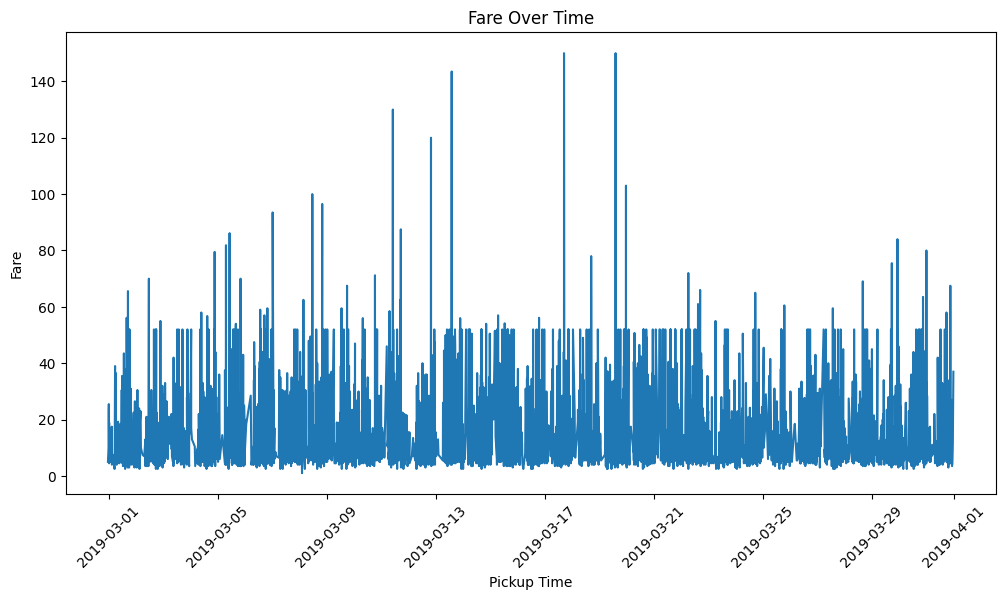

In [ ]:
# CREATE LINE CHART - FARE OVER TIME
# Convert pickup column to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort data by pickup time
df = df.sort_values('pickup')

# Plot fare over time
plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'])

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=45)
plt.show()


**Observation:** Fare values vary considerably over time, with several noticeable spikes in the series.

**★ Bar Chart**
Create a bar chart to show the total fare for each pickup_borough. Group the data by
pickup_borough and sum the fare for each group.

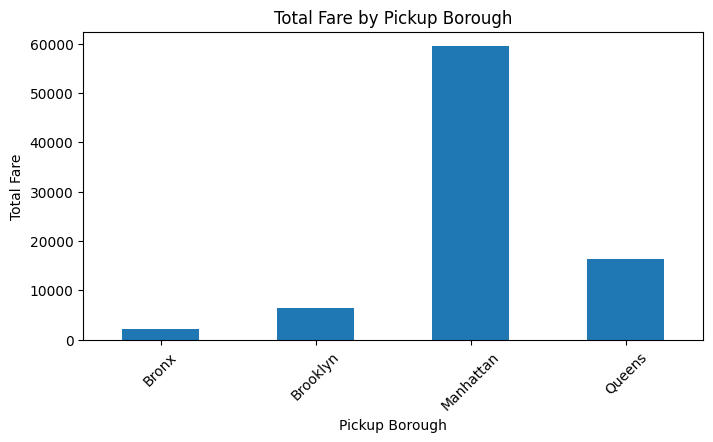

In [ ]:
#calculate total fare using groupby
total_fare = df.groupby('pickup_borough')['fare'].sum()

# Create bar chart
plt.figure(figsize=(8, 4))
total_fare.plot(kind='bar')

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

**Observation:** Manhattan contributes the largest total fare, followed by Queens. Brooklyn and Bronx contribute smaller totals in the displayed dataset.

**★ Pie Chart**
Plot a pie chart showing the distribution of trips based on the payment method (credit card,
cash, etc.). Each slice should represent the count of trips for a specific payment method.

([<matplotlib.patches.Wedge at 0x7b2f64640410>,
 [Text(-1.0999176579877006, 0.01345903588121957, 'credit card'),
  Text(1.0999176559554302, -0.013459201964165125, 'cash')],
 [Text(-0.5999550861751093, 0.0073412922988470375, '71.83%'),
  Text(0.5999550850665982, -0.007341382889544613, '28.17%')])

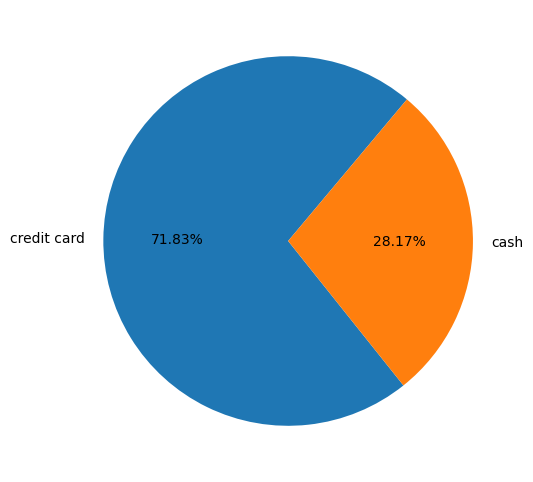

In [ ]:
# Count the number of trips for each payment method
payment_counts = df['payment'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(payment_counts,labels=payment_counts.index, autopct='%1.2f%%',startangle=50)


**Observation:** The chart shows:

**Credit card: 71.83%**

**Cash: 28.17%**

This indicates that credit-card transactions account for the majority of trips represented in the visualization.

**★ Histogram**
Create a histogram to visualize the distribution of distance. Customize the number of bins for
better granularity and ensure the plot is easy to interpret.

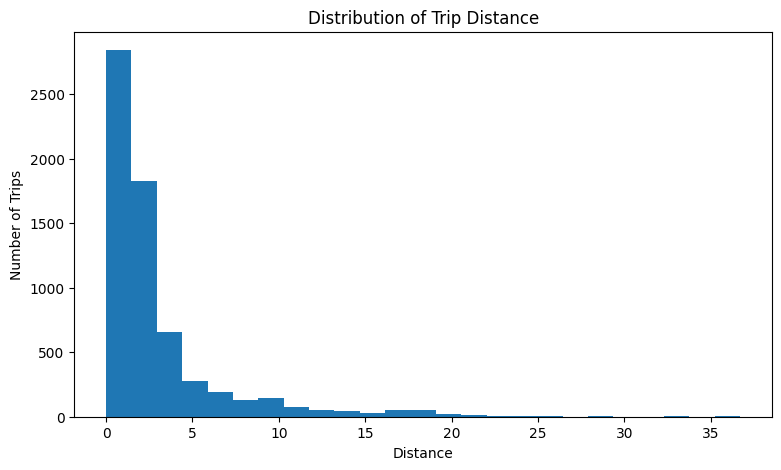

In [ ]:
# Create histogram
plt.figure(figsize=(9, 5))

plt.hist(df['distance'], bins=25)

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Distance')

plt.show()

**Observation:** Trip distance is strongly concentrated at shorter distances, while a smaller number of trips extend to much longer distances. The distribution is therefore right-skewed.

**★ Box Plot**
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use
pickup_borough as the categorical axis and tip as the numeric axis.

/tmp/ipykernel_1811/35848769.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


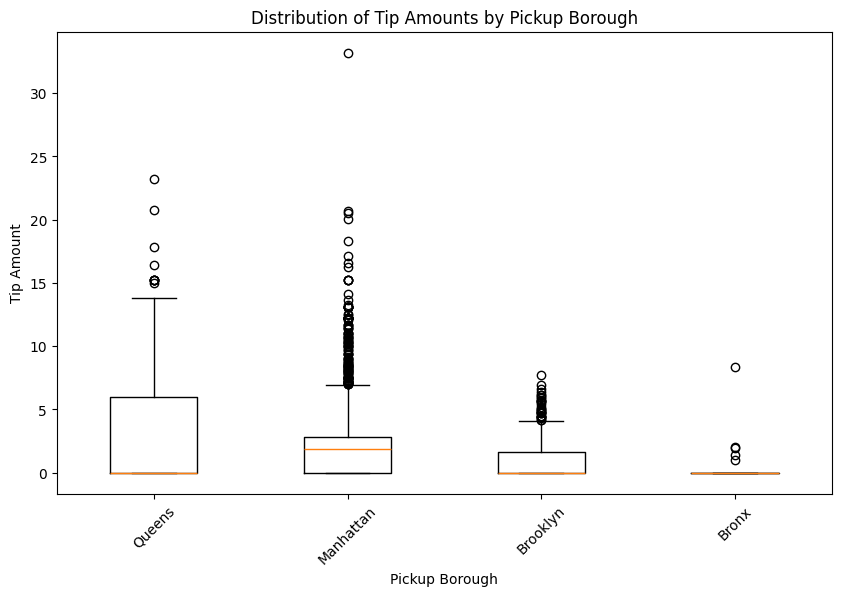

In [ ]:
# Create box plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[df['pickup_borough'] == borough]['tip'].dropna()
     for borough in df['pickup_borough'].dropna().unique()],
    labels=df['pickup_borough'].dropna().unique()
)

plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.xticks(rotation=45)

plt.show()

**Observation:** Tip values are concentrated near the lower end, with several higher-value outliers. The boroughs show differences in spread and the presence of extreme tip values.

# **5) Visualizations using Seaborn:**

**★ Count Plot**
Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should
represent the boroughs, and the y-axis should show the count of trips.

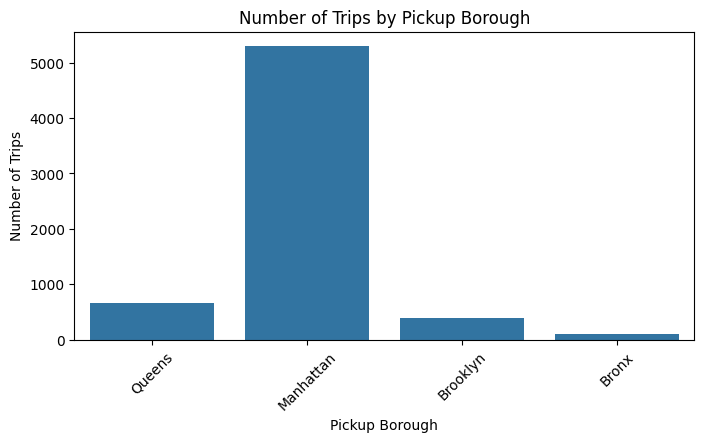

In [ ]:
# Create count plot
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='pickup_borough')

plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

**Observation:** Manhattan has the highest trip volume in the displayed dataset, while Bronx has the lowest among the four shown boroughs.

**★ Scatter Plot**
Plot a scatter plot to show the relationship between distance and fare. Use distance on the
x-axis and fare on the y-axis to visualize any correlation. Color the points based on the
pickup_borough to differentiate the trips by their respective boroughs.

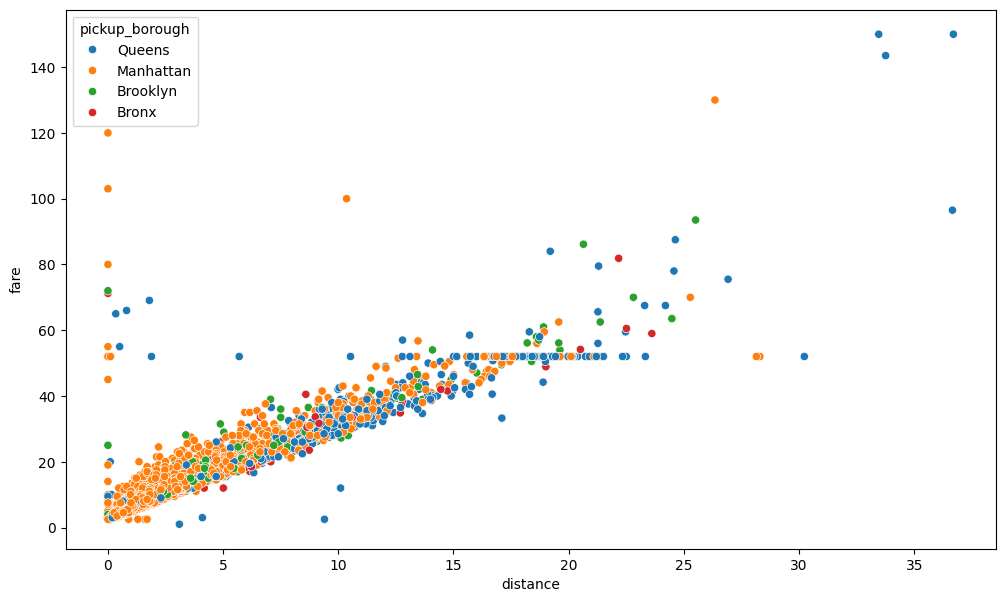

In [ ]:
# Create the Scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df,x="distance",y="fare",hue="pickup_borough")
plt.show()

**Observation:** The scatter plot shows a strong positive relationship: as distance increases, fare generally increases. A few higher-distance/high-fare observations and outliers are also visible.

**★ Heatmap**
Plot a heatmap to visualize the correlation between numerical variables such as distance, fare,
tip, tolls, and total. Use a correlation matrix to highlight the relationships.

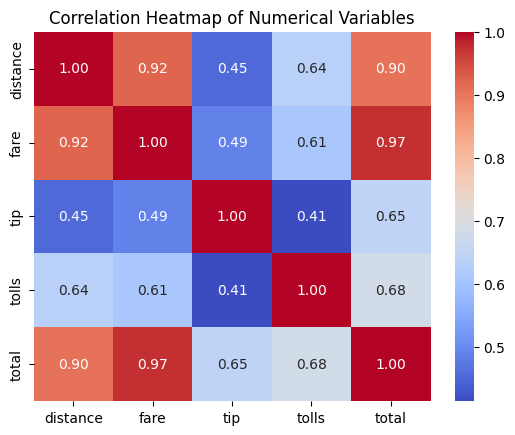

In [ ]:
# Select numerical columns
columns = ['distance', 'fare', 'tip', 'tolls', 'total']

# Create correlation matrix
correlation_matrix = df[columns].corr()

# Plot heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Key observation:** Fare and total have the strongest relationship in the displayed correlation matrix (0.97). Distance and fare also have a strong positive correlation (0.92).

Pair Plot

Purpose: Examine pairwise relationships between:

Distance

Fare

Tip

Total

The pair plot helps identify linear relationships, distributions, clusters, and potential outliers across multiple numerical variables.

Pair Plot by Pickup Zone

The pairwise relationships were also visualized using pickup_zone as the hue/category. This allows the numerical patterns to be compared across different pickup zones.

**★ Pair Plot**
Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total.
Color the data points according to the pickup_zone column. to compare how different zones
affect these variables.

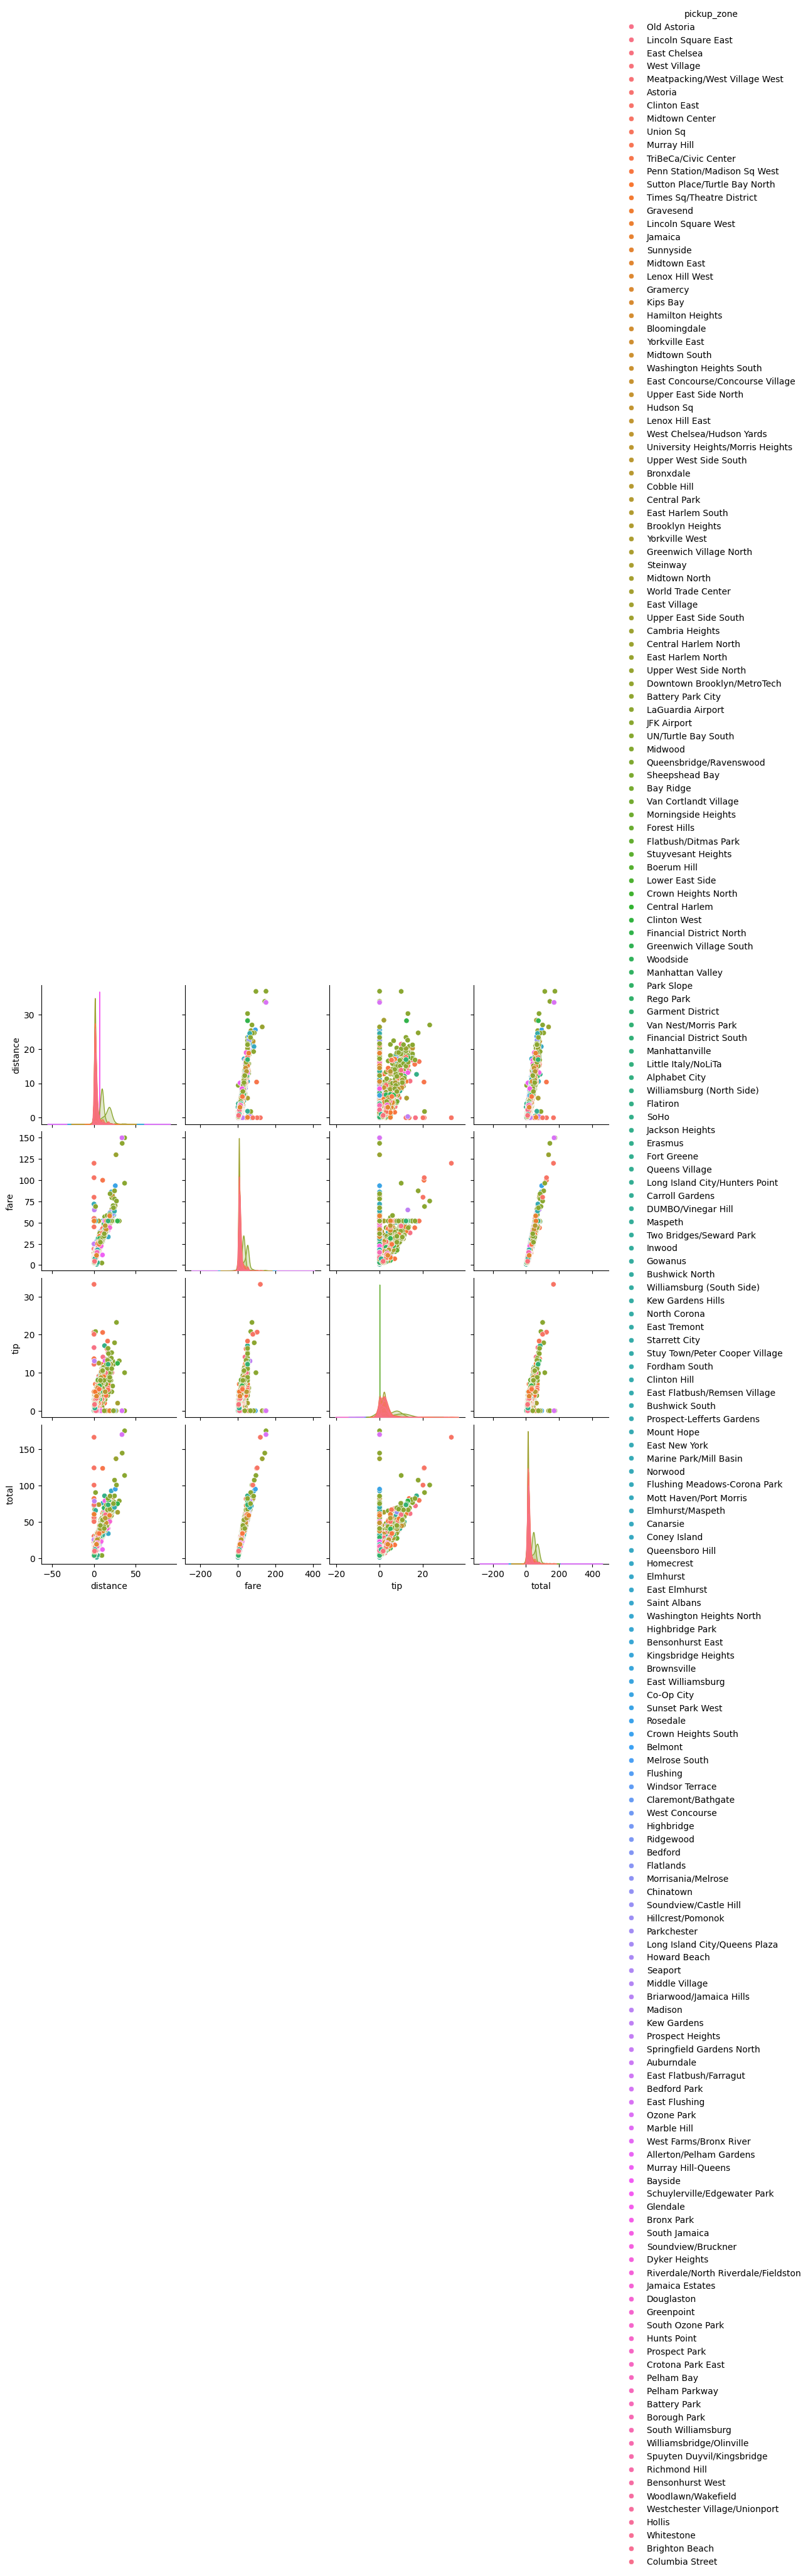

In [ ]:
# Create pair plot
columns = ['distance', 'fare', 'tip', 'total', 'pickup_zone']
sns.pairplot(df[columns],hue='pickup_zone')
plt.show()

**★ Violin Plot**
Plot a violin plot to show the distribution of fare for each payment method. Use the payment
method as the categorical axis and fare as the numeric axis to visualize its distribution.

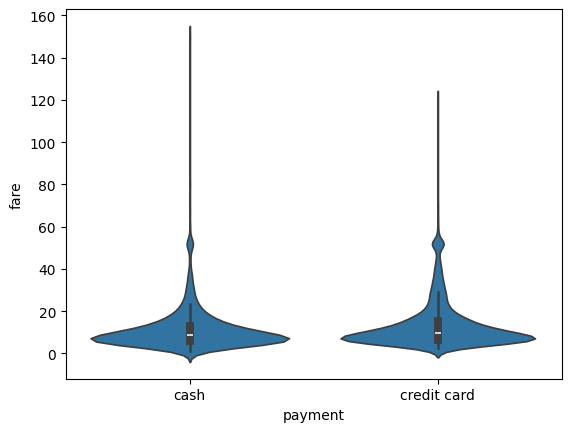

In [ ]:
#Cretae Violin Plot
sns.violinplot(data=df, x="payment",y="fare")
plt.show()

**Observation:** Both payment methods show concentrated fare distributions at lower values, with longer upper tails representing higher-fare trips. The displayed distributions also contain higher-value observations/outliers.

# **Conclusion**
This project provides a clear overview of taxi trip behavior using Python-based data analysis and visualization.

The analysis shows that Manhattan is the dominant pickup borough by trip volume and total fare. Most trips are relatively short, while longer trips are associated with higher fares. Credit-card payments dominate the displayed transactions, and the correlation analysis confirms strong relationships among distance, fare, and total trip value.